---
title: Telco Customer Churn Analysis
author: Pride M.J Mnisi
format:
  html:
    embed-resources: true
    theme: cosmo
    
  pdf: default

toc: true
echo: false
warning: false
jupyter: python3
---

# Report

::: {.content-hidden}

# Imports

In [ ]:
import pandas as pd
import matplotlib.pyplot as plt
import numpy as np

# Usesful variables
font_title = {'family': 'Times New Roman', 'weight': 'bold', 'size': 14}
font_labels = {'family': 'Times New Roman', 'size': 12}
grid_style = {'linestyle': '--', 'alpha': 0.8, 'zorder': 0, 'axis':'y'}

# Data Cleaning
## Understanding the 


### First 5 Rows

In [ ]:
df = pd.read_csv("WA_Fn-UseC_-Telco-Customer-Churn.csv")
df.head() #First 5 rows of the dataset

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,0,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,0,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.5,No
2,3668-QPYBK,Male,0,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,0,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,0,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


### Information

In [ ]:
df.info() #Information about the dataset

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

The TotalCharges column seems to be a str type rather than a float which will require some reformatting

### Data description

In [ ]:
df.describe() #Statistical summary of the dataset

,SeniorCitizen,tenure,MonthlyCharges
count,7043.000000,7043.000000,7043.000000
mean,0.162147,32.371149,64.761692
std,0.368612,24.559481,30.090047
min,0.000000,0.000000,18.250000
25%,0.000000,9.000000,35.500000
50%,0.000000,29.000000,70.350000
75%,0.000000,55.000000,89.850000
max,1.000000,72.000000,118.750000


Since TotalCharges is non-numeric then we cannot see it on the summary

### Null entries

In [ ]:
df.isnull().sum() #Check for missing values in the dataset per column

customerID          0
gender              0
SeniorCitizen       0
Partner             0
Dependents          0
tenure              0
PhoneService        0
MultipleLines       0
InternetService     0
OnlineSecurity      0
OnlineBackup        0
DeviceProtection    0
TechSupport         0
StreamingTV         0
StreamingMovies     0
Contract            0
PaperlessBilling    0
PaymentMethod       0
MonthlyCharges      0
TotalCharges        0
Churn               0
dtype: int64

No null values detected

## Data Formatting

### Formating TotalCharges

In [ ]:
print(df['TotalCharges'].unique()[:20])
print(df['TotalCharges'].value_counts().head(20)) 

#I'm using these 2 lines to show the unique values in 'TotalCharges'
#The first line prints the unique values in the 'TotalCharges' column, but only the first 20 unique values to avoid overwhelming output. 
# The second line counts how many times each unique value appears in the 'TotalCharges' column and then displays the top 20 most common values along with their counts. 
# This helps to identify any anomalies or patterns in the 'TotalCharges' data, such as non-numeric entries or outliers.

<StringArray>
[  '29.85',  '1889.5',  '108.15', '1840.75',  '151.65',   '820.5',  '1949.4',
   '301.9', '3046.05', '3487.95',  '587.45',   '326.8',  '5681.1',  '5036.3',
 '2686.05', '7895.15', '1022.95', '7382.25',  '528.35',  '1862.9']
Length: 20, dtype: str
TotalCharges
20.2     11
         11
19.75     9
19.9      8
20.05     8
19.65     8
45.3      7
19.55     7
20.15     6
19.45     6
20.25     6
20.45     5
20.3      5
74.7      4
70.6      4
44        4
75.3      4
20.4      4
19.85     4
49.9      4
Name: count, dtype: int64


The data frame seems to contain empty srtings which need to be handled

In [ ]:
df['TotalCharges'] = pd.to_numeric(df['TotalCharges'], errors='coerce')


# Calculate missing values using tenure * MonthlyCharges
df['TotalCharges'] = df['TotalCharges'].fillna(df['tenure'] * df['MonthlyCharges'])

#Here is the new dataset information after cleaning TotalCharges column
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 7043 entries, 0 to 7042
Data columns (total 21 columns):
 #   Column            Non-Null Count  Dtype  
---  ------            --------------  -----  
 0   customerID        7043 non-null   str    
 1   gender            7043 non-null   str    
 2   SeniorCitizen     7043 non-null   int64  
 3   Partner           7043 non-null   str    
 4   Dependents        7043 non-null   str    
 5   tenure            7043 non-null   int64  
 6   PhoneService      7043 non-null   str    
 7   MultipleLines     7043 non-null   str    
 8   InternetService   7043 non-null   str    
 9   OnlineSecurity    7043 non-null   str    
 10  OnlineBackup      7043 non-null   str    
 11  DeviceProtection  7043 non-null   str    
 12  TechSupport       7043 non-null   str    
 13  StreamingTV       7043 non-null   str    
 14  StreamingMovies   7043 non-null   str    
 15  Contract          7043 non-null   str    
 16  PaperlessBilling  7043 non-null   str    
 17  Paymen

### Readability Improvements

Having "None" instead of "No" in a category imporoves readability, especially in visuals and creates a better presentation.

In [ ]:
df['InternetService'] = df['InternetService'].replace('No', 'None')

I'll map 0 to 'No' and 1 to 'Yes' in SeniorCitizen column for better readability

In [ ]:
df['SeniorCitizen'] = df['SeniorCitizen'].map({0: 'No', 1: 'Yes'}) 

:::

# Churn Analysis

## Preview

In [ ]:
df.head()

,customerID,gender,SeniorCitizen,Partner,Dependents,tenure,PhoneService,MultipleLines,InternetService,OnlineSecurity,...,DeviceProtection,TechSupport,StreamingTV,StreamingMovies,Contract,PaperlessBilling,PaymentMethod,MonthlyCharges,TotalCharges,Churn
0,7590-VHVEG,Female,No,Yes,No,1,No,No phone service,DSL,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,29.85,29.85,No
1,5575-GNVDE,Male,No,No,No,34,Yes,No,DSL,Yes,...,Yes,No,No,No,One year,No,Mailed check,56.95,1889.50,No
2,3668-QPYBK,Male,No,No,No,2,Yes,No,DSL,Yes,...,No,No,No,No,Month-to-month,Yes,Mailed check,53.85,108.15,Yes
3,7795-CFOCW,Male,No,No,No,45,No,No phone service,DSL,Yes,...,Yes,Yes,No,No,One year,No,Bank transfer (automatic),42.30,1840.75,No
4,9237-HQITU,Female,No,No,No,2,Yes,No,Fiber optic,No,...,No,No,No,No,Month-to-month,Yes,Electronic check,70.70,151.65,Yes


## Overall Churn Rate

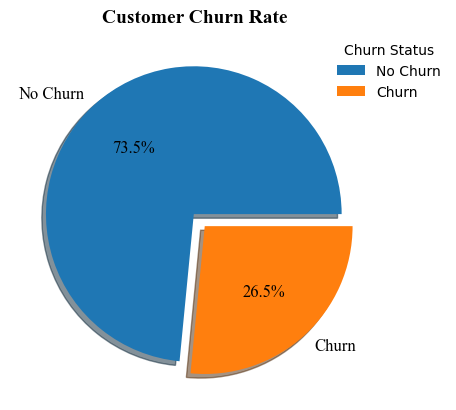

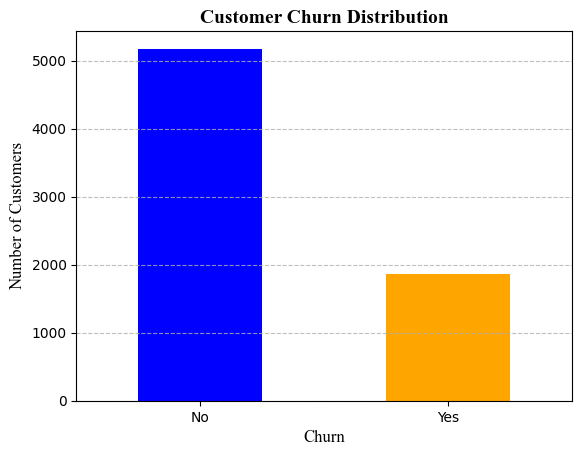

In [ ]:
churn_rate = df['Churn'].value_counts(normalize=True) 

plt.pie(churn_rate*100, 
        labels=['No Churn', 'Churn'],
        textprops=font_labels, 
        explode=(0.01,0.1), shadow=True, 
        autopct='%1.1f%%') #autopct adds percentage labels to the pie chart
plt.title("Customer Churn Rate", fontdict=font_title)
plt.legend(title='Churn Status', loc='upper right', labels=['No Churn', 'Churn'], fontsize=10, frameon=False, bbox_to_anchor=(1.2, 1))

plt.show()
#print(churn_rate)


df['Churn'].value_counts().plot(kind='bar', color=['blue', 'orange'])
plt.grid(True, **grid_style) 
plt.title("Customer Churn Distribution", fontdict=font_title)
plt.xlabel("Churn", fontdict=font_labels)
plt.ylabel("Number of Customers", fontdict=font_labels)
plt.xticks(rotation=0)
plt.show()

#print(df['customerID'].count()) #Total number of customers in the dataset)

The company is experiencing a relatively high churn rate (1,868 of 7,043 customers) indicating a significant loss of customers and potential revenue. Immediate retention strategies are required, particularly targeting high-risk segments.

---

## Churn by Contract

Contract type is a strong predictor of churn.  Customers without long-term commitment are far more likely to leave.

In [ ]:
contract_churn = pd.crosstab(df['Contract'], df['Churn'], normalize='index') * 100

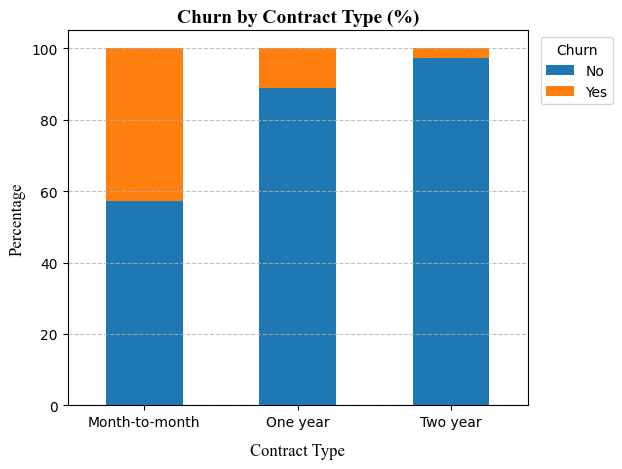

In [ ]:
import matplotlib.pyplot as plt
contract_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Contract Type (%)", fontdict=font_title)
plt.ylabel("Percentage", fontdict=font_labels)
plt.xlabel("Contract Type", fontdict=font_labels, labelpad=10, ha='center')
plt.legend(title='Churn', loc='upper right', fontsize=10, bbox_to_anchor=(1.2, 1))
plt.grid(True, **grid_style)
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

**Keys observations:**
Customers on month-to-month contracts have a significantly higher churn rate, roughly 43%, compared to one-year, which is 11%, and two-year contracts, which is appproximately 3% of all customers in the two year contract.

- **Retention Driver:**
    - Longer commitments equate to lower churn. Customers who sign longer contracts are 15x more likely to stay than month-to-month customers.

**Measure to minimize churn:**

- **Targeted Strategies:** Incentives for annual prepayment can be offered, like one month free. This gives the customers something to look forward to.
- Or monthly trials could be utilised to show customer the value the business is to them, (e.g. a "3-month trial" that auto-converts to annual contract)
- Have loyalty rewards

---

## Churn by Tenure

The previous results already show how much the time customers have been with us contrivutes to churn.

The graph below will show the rate of churn and retention with how long a customer has been with the company (in months).

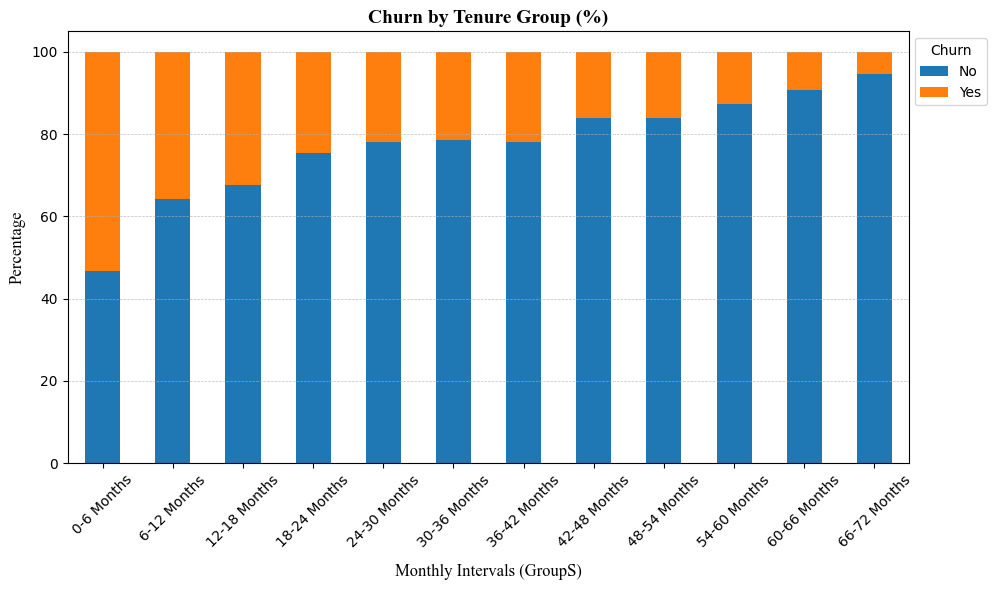

In [ ]:
#===========Creating tenure groups===========

df['tenure_group'] = pd.cut( #cuts the 'tenure' column into specified bins and assigns labels to those bins, creating a new column called 'tenure_group'.
    df['tenure'], #This is the column that we want to cut so that we can analyze customer churn based on how long they have been with the company.
    bins=[0, 6, 12, 18, 24, 30, 36, 42, 48, 54, 60, 66, 72], #These are the edges of the bins. The first bin will include values from 0 to 12 months, the second bin from 12 to 24 months, the third bin from 24 to 48 months, and the fourth bin from 48 to 72 months.
    labels=['0-6 Months', '6-12 Months', '12-18 Months', '18-24 Months', '24-30 Months', '30-36 Months', '36-42 Months', '42-48 Months', '48-54 Months', '54-60 Months', '60-66 Months', '66-72 Months'] #These are the labels for each bin.
) 

#===========Calculating churn rate by tenure group===========

tenure_churn = pd.crosstab( #cross-tab simply computes a cross-tabulation of two factors. 
    df['tenure_group'], df['Churn'], normalize='index' #so rn it's calculating the percentage of customers who churned and did not churn for each tenure group.
) * 100

#===========Plotting the churn rate by tenure group===========
tenure_churn.plot(kind='bar', stacked=True, figsize=(10, 6))

plt.title("Churn by Tenure Group (%)", fontdict=font_title)
plt.xlabel("Monthly Intervals (GroupS)", fontdict=font_labels, labelpad=10, ha='center')
plt.ylabel("Percentage", fontdict=font_labels)
plt.xticks(rotation=45)
plt.legend(title='Churn', loc='upper right', bbox_to_anchor=(1.1, 1))
plt.grid(True, **grid_style, linewidth=0.5)
plt.tight_layout()
#print(tenure_churn)
plt.show()

**Key observations:**
    New customers are the biggest risk. In the first 6 Months, over half (roughly 53.3%) of the new customers leave.
    At this point, customers have not committed meaning competitors are still high and the more time it takes the business to be of value to them, the greater the chances of customers leaving increasing churn. 
    Onboarding & early experience matter most.

- **Retention Driver:** 
    - Time = loyalty. Once customers pass the 1-year mark, churn drops dramatically

**Measures to minimize churn:**

- **Targeted Retention Strategies:** Since the first are a risk, identinify the customers not using the service actively and reach out to them with personalized offers or support to encourage continued engagement.

- **Loyalty Programs**: For customers in the mid-tenure groups (24-36 months), reward long-term commitment.
    
- **Feedback Mechanisms**: For customers in the later tenure groups, establish feedback mechanisms to understand their evolving needs and preferences. This helps retain the loyal customers we have.

---

## Churn by Total Charges

Total charges is a measure of how much revenue a customer has generated for the company. By grouping customers based on their total charges and analyzing the churn rate within each group, we can identify if there are specific spending patterns that correlate with higher or lower churn rates. This can help the company to target retention efforts more effectively, such as offering special promotions or personalized services to high-value customers who may be at risk of churning.

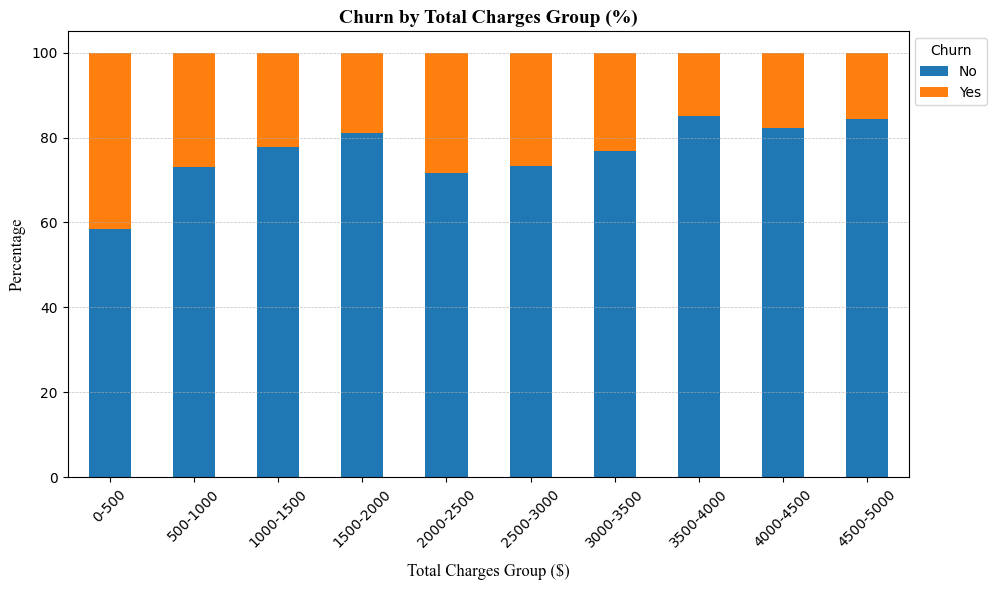

In [ ]:
##============Churn by total charges group============
df['TotalCharges_grp'] = pd.cut(
    df['TotalCharges'],
    bins=[0, 500, 1000, 1500, 2000, 2500, 3000, 3500, 4000, 4500, 5000],
    labels=['0-500', '500-1000', '1000-1500', '1500-2000', '2000-2500', '2500-3000', '3000-3500', '3500-4000', '4000-4500', '4500-5000']
)
total_charges_churn = pd.crosstab(
    df['TotalCharges_grp'], df['Churn'], normalize='index') * 100
total_charges_churn.plot(kind='bar', stacked=True, figsize=(10, 6))
plt.title("Churn by Total Charges Group (%)", fontdict=font_title)
plt.xlabel("Total Charges Group ($)", fontdict=font_labels, labelpad=10, ha='center')
plt.ylabel("Percentage", fontdict=font_labels)
plt.xticks(rotation=45)
plt.legend(title='Churn', bbox_to_anchor=(1.1, 1), fontsize=10)
plt.grid(True, **grid_style, linewidth=0.5)
plt.tight_layout()
#print(total_charges_churn) 
plt.show()

**Key Observations:**
- **Retention Driver:**
    - Customers who accumulate higher total charges have invested more and tend to stay.
    - TotalCharges is **NOT** a strong independent driver of churn
- **Note on trend:** 
    - The trend is almost horizontal meaning that after initial period, total charges isn't a strong predictor - once customers survive first ~6 months, they're likely to stay regardless of bill size.
    - While customers with low total charges exhibit higher churn, this is primarily due to their short tenure. Total charges alone is not a strong predictor of churn, but rather a reflection of customer lifetime

---

## Churn by Internet Service

This section analyzes the churn rate based on the type of internet service customers have. The dataset categorizes internet service into three types: 'DSL', 'Fiber optic', and 'None'. By calculating the percentage of customers who churned within each internet service category, we can identify if there are any significant differences in churn rates among these groups. This analysis can help the company understand if certain internet service types are associated with higher customer dissatisfaction and churn, which can inform targeted retention strategies.

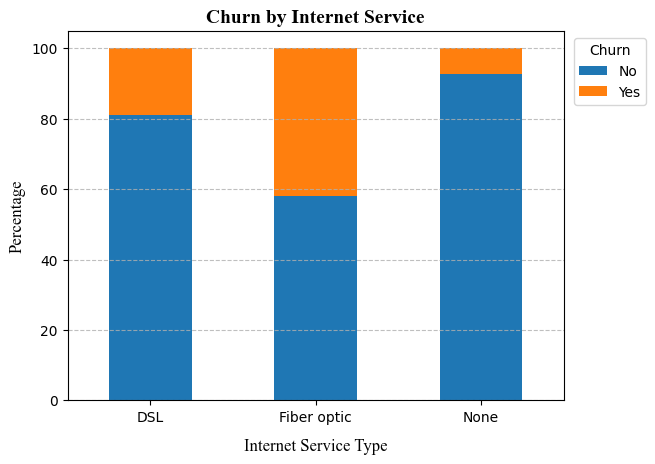

In [ ]:
internet_churn = pd.crosstab(df['InternetService'], df['Churn'], normalize='index') * 100
internet_churn.plot(kind='bar', stacked=True)
plt.title("Churn by Internet Service", fontdict=font_title)
plt.ylabel("Percentage", fontdict=font_labels)
plt.xlabel("Internet Service Type", fontdict=font_labels, labelpad=10, ha='center')
plt.legend(title='Churn', loc='upper right', fontsize=10, bbox_to_anchor=(1.18, 1))
plt.grid(True, **grid_style)
plt.xticks(rotation=0)
plt.show()
#print(internet_churn)

**Key Obsertion:**

Customers with Fiber optic internet service have a significantly higher churn rate (around 42%) compared to those with DSL (around 14%) and None (around 10%).

The majority of customers with Fiber optic service are churning, which indicates a potential issue with the service quality or customer satisfaction for that group.

Customers with no internet service (None) have the lowest churn rate, which may suggest that these customers are less likely to churn due to the absence of internet-related issues or dissatisfaction.

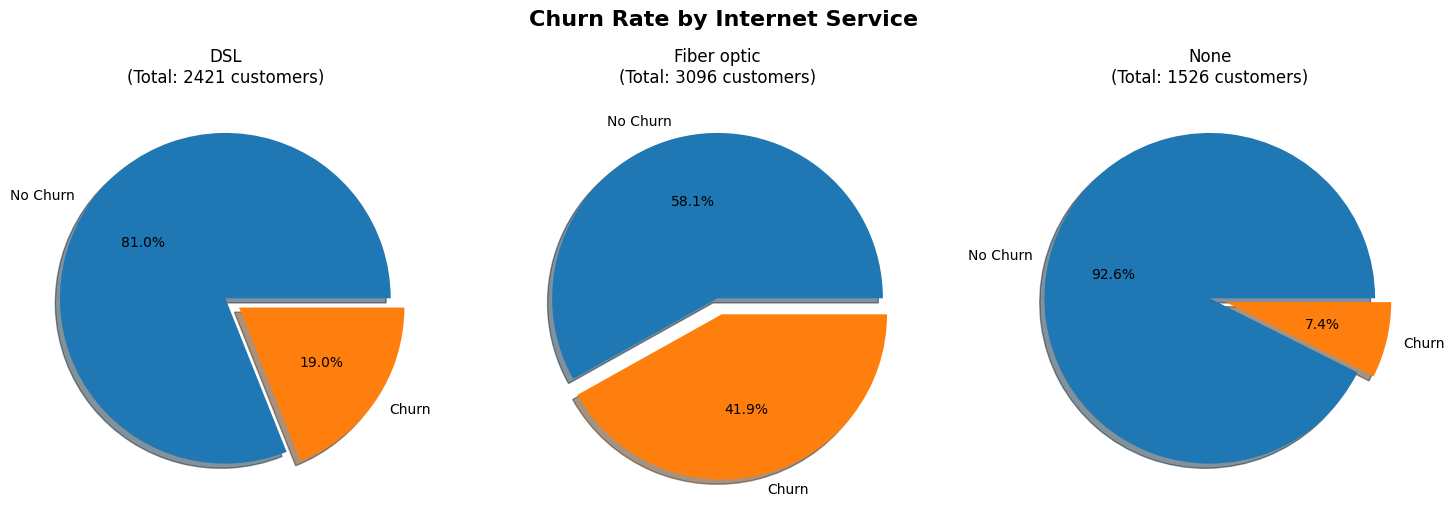

In [ ]:
internet_churn = pd.crosstab(df['InternetService'],
                             df['Churn'],
                               normalize='index') * 100 #Gets ratio of churn for each internet service type, normalized by the index (which is the internet service type in this case). 

# Create pie chart for each internet service type
fig, axes = plt.subplots(1, 3, figsize=(15, #width 
                                        5 #height
                                        ))

internet_services = internet_churn.index.tolist()

for i, service in enumerate(internet_services):
    churn_data = internet_churn.loc[service]
    axes[i].pie(churn_data, 
                labels=['No Churn', 'Churn'],
                autopct='%1.1f%%',
                explode=(0, 0.1),
                shadow=True,
                )
    axes[i].set_title(f"{service}\n(Total: {df[df['InternetService'] == service].shape[0]} customers)")
    #print(f"{service}\n(Total: {df[df['InternetService'] == service].shape[0]} customers)")

plt.suptitle("Churn Rate by Internet Service", fontsize=16, weight='bold', y=1.02)
plt.tight_layout()
plt.show()
# Print the data
#print(internet_churn)

**Possible Drivers to Investigate:**
- How customers perceive Fiber Optics
- Service reliability
- Competitors offering better fiber deals

**Recommendation:**
- URGENT: Survey fiber optic churners to identify what leads to customer dissatisfaction
- Survey both DSL and fiber opitcs to compare customers' feedback on both services
- Explore potential improvements to both the fiber optic and DSL service, such as enhancing network infrastructure, offering better customer support, or providing incentives to retain customers who are at risk of churning due to dissatisfaction with their internet service.
- Guide customers to the RIGHT service for THEIR needs (which service is for what type of user) not just the most expensive or fastest option.


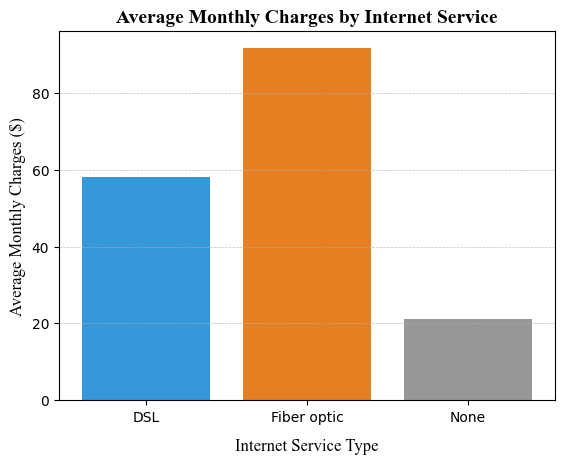

In [ ]:
#==========Pricing of Internet Services===============
prices = df.groupby('InternetService')['MonthlyCharges'].mean()
plt.bar(prices.index, prices.values, color=['#3498db', '#e67e22', "#979797"])
plt.title("Average Monthly Charges by Internet Service", fontdict=font_title)  
plt.xlabel("Internet Service Type", fontdict=font_labels, labelpad=10, ha='center')
plt.ylabel("Average Monthly Charges ($)", fontdict=font_labels)
plt.grid(True, **grid_style, linewidth=0.5)
plt.show()
#print(prices)

Fiber optic customers pay nearly 60% more than DSL customers, yet they churn at 42% vs DSL's 19%. This suggests that customers pay more, but they're not experiencing enough value to justify the cost.

---

# Summary

The analysis shows that customer churn (**roughly 26.5%**) is primarily **driven by early-stage disengagement, low contract commitment, and fiber optic service usage (expextations not being met)**. Customers in their **first 6 months** and those on **month-to-month plans** are the **most likely to churn**, while **long-term customers** (higher tenure) **demonstrate strong retention**. This highlights a clear customer lifetime trend: the longer a customer stays, the less likely they are to leave. Although total charges appear related to churn, this is **largely due to their correlation with tenure rather than being a direct driver. Fiber optic users exhibit the highest churn rates**, suggesting potential issues with pricing or service quality. **Overall**, customers tend to stay longer once they pass the early stages, indicating that **improving onboarding, encouraging long-term contracts, and addressing fiber-related concerns** would significantly improve retention.

---
